In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nisargpatel344/student-course-completion-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-course-completion-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/student-course-completion-prediction-dataset


In [1]:
!pip install protobuf==3.20.3
import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
path = kagglehub.dataset_download("nisargpatel344/student-course-completion-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-course-completion-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/student-course-completion-prediction-dataset


In [3]:
print(os.listdir(path))

['Course_Completion_Prediction.csv']


In [4]:
df = pd.read_csv(os.path.join(path,'Course_Completion_Prediction.csv'))

In [5]:
pd.set_option('display.max_columns', None)  # it'll Show All Cols

In [6]:
df.head()

,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,Category,Course_Level,Course_Duration_Days,Instructor_Rating,Login_Frequency,Average_Session_Duration_Min,Video_Completion_Rate,Discussion_Participation,Time_Spent_Hours,Days_Since_Last_Login,Notifications_Checked,Peer_Interaction_Score,Assignments_Submitted,Assignments_Missed,Quiz_Attempts,Quiz_Score_Avg,Project_Grade,Progress_Percentage,Rewatch_Count,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,Data Analysis with Python,Programming,Intermediate,60,4.7,3,30,55.0,2,0.5,1,6,4.3,8,1,5,80.9,71.2,70.8,0,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,Machine Learning A-Z,Programming,Advanced,90,4.6,4,37,84.1,2,0.9,3,5,7.8,4,6,3,78.4,42.5,55.6,2,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,Python Basics,Programming,Beginner,45,4.6,5,9,75.6,3,0.5,19,5,6.7,8,2,3,100.0,87.9,78.8,2,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,UI/UX Design Fundamentals,Design,Beginner,40,4.4,2,27,63.3,1,7.4,19,9,6.4,0,10,4,59.1,51.4,24.7,4,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,Machine Learning A-Z,Programming,Advanced,90,4.6,2,36,86.4,1,0.5,4,7,7.5,5,5,8,84.8,93.0,64.9,4,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


In [7]:
df.isna().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(100000, 40)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Student_ID                    100000 non-null  object 
 1   Name                          100000 non-null  object 
 2   Gender                        100000 non-null  object 
 3   Age                           100000 non-null  int64  
 4   Education_Level               100000 non-null  object 
 5   Employment_Status             100000 non-null  object 
 6   City                          100000 non-null  object 
 7   Device_Type                   100000 non-null  object 
 8   Internet_Connection_Quality   100000 non-null  object 
 9   Course_ID                     100000 non-null  object 
 10  Course_Name                   100000 non-null  object 
 11  Category                      100000 non-null  object 
 12  Course_Level                  100000 non-null

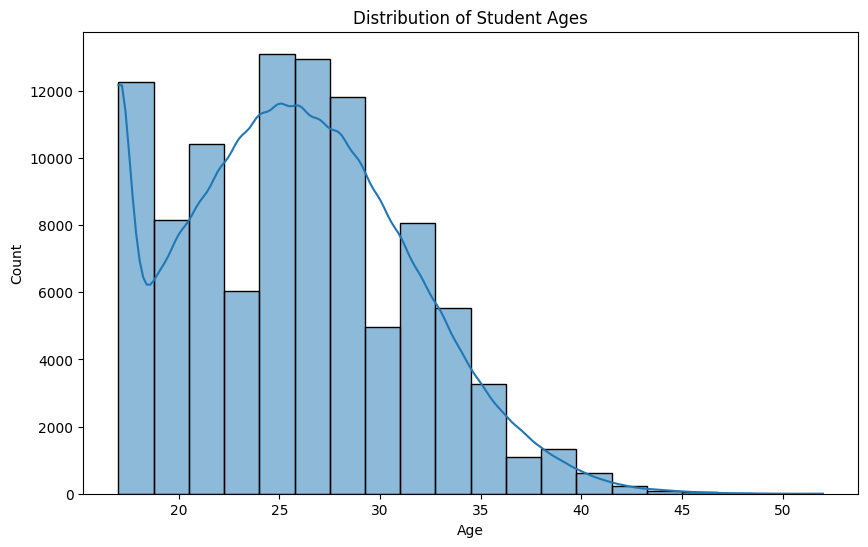

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Student Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

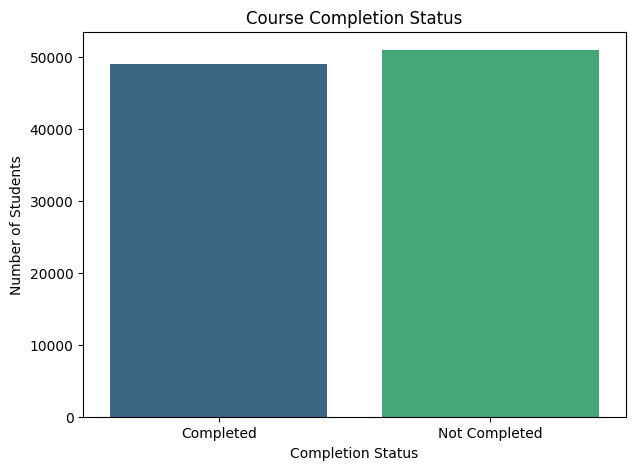

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Completed', data=df, hue='Completed', palette='viridis')
plt.title('Course Completion Status')
plt.xlabel('Completion Status')
plt.ylabel('Number of Students')
plt.show()

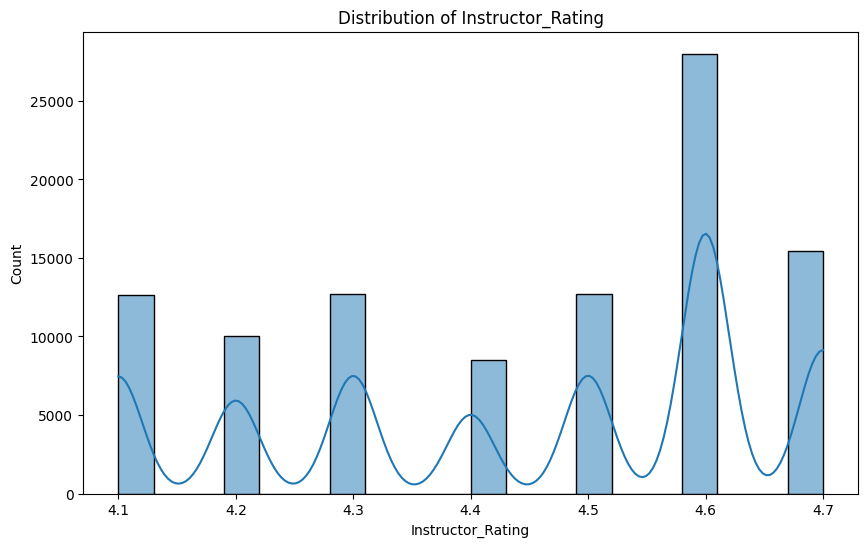

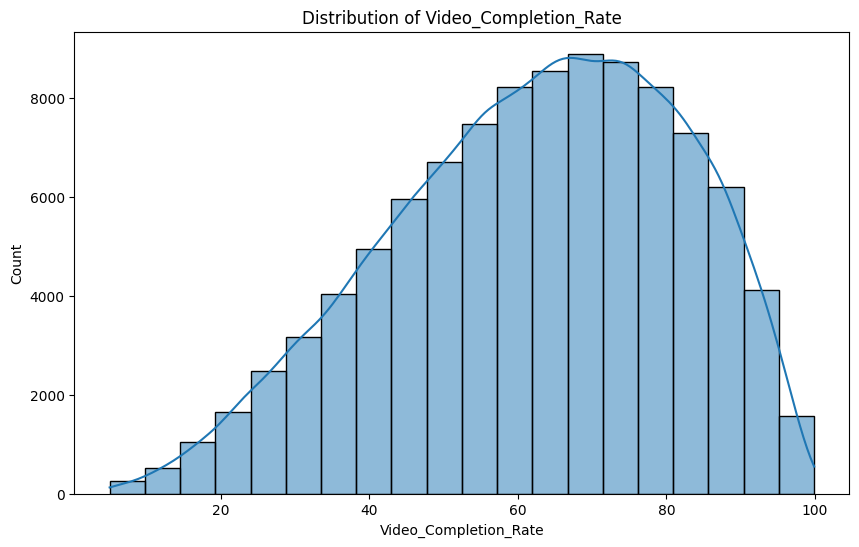

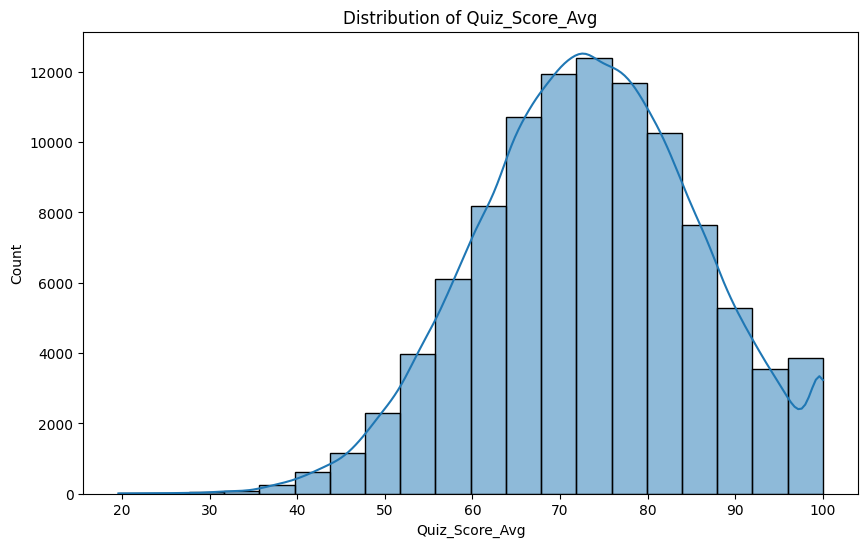

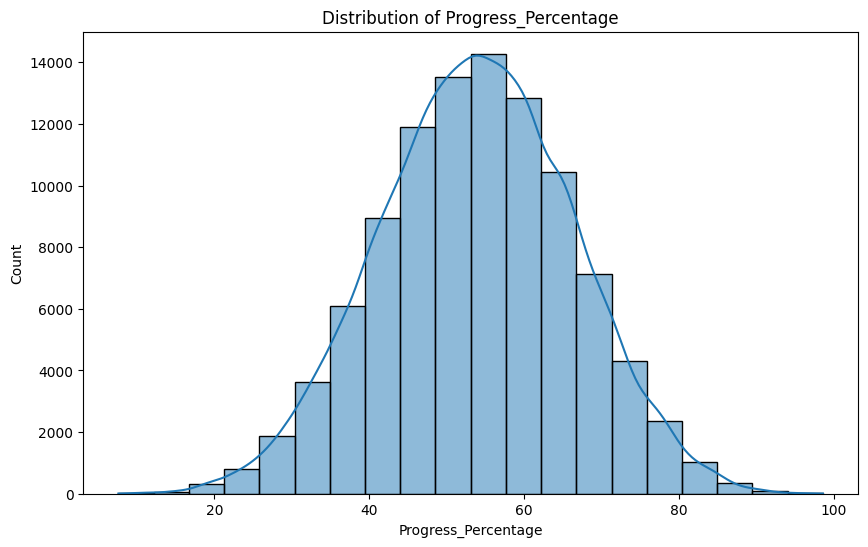

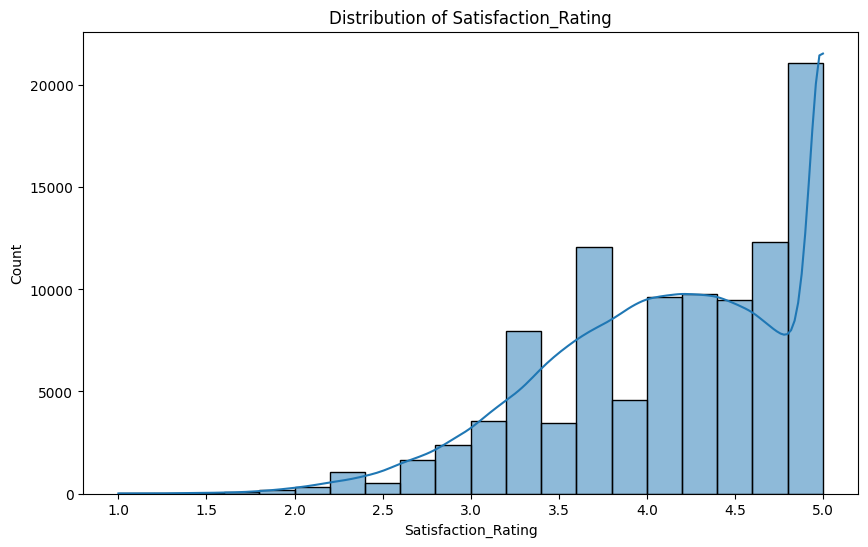

In [13]:
numerical_cols = ['Instructor_Rating', 'Video_Completion_Rate', 'Quiz_Score_Avg', 'Progress_Percentage', 'Satisfaction_Rating']

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()